In [644]:
# Standard imports
import sys, os

import pandas as pd
pd.set_option("display.max_rows", 101)
pd.set_option("display.max_columns", 101)

import matplotlib.pyplot as plt


In [645]:
# Import Metrica helper files
import Metrica_IO as mio
import Metrica_Viz as mviz

In [646]:
# Absolute path to your sample-data folder
DATADIR = "/Users/christinasupino/sample-data/data"
game_id = 2

In [647]:
# read in the event data
events = mio.read_event_data(DATADIR,game_id)

In [648]:
# count the number of each event type in the data
print( events['Type'].value_counts() )

Type
PASS              964
CHALLENGE         311
RECOVERY          248
BALL LOST         233
SET PIECE          80
BALL OUT           49
SHOT               24
FAULT RECEIVED     20
CARD                6
Name: count, dtype: int64


In [649]:
#Unit conversion from metrica data units to meters
events = mio.to_metric_coordinates(events)

In [650]:
events

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,51,2.04,51,2.04,Player23,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,51,2.04,87,3.48,Player23,Player20,0.00,-0.00,-10.60,-0.68
2,Away,PASS,NaN,1,146,5.84,186,7.44,Player20,Player18,-7.42,-0.00,-6.36,19.04
3,Away,PASS,NaN,1,248,9.92,283,11.32,Player18,Player17,-3.18,21.08,-20.14,14.96
4,Away,PASS,NaN,1,316,12.64,346,13.84,Player17,Player16,-22.26,12.24,-25.44,-5.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,Away,BALL LOST,INTERCEPTION,2,140122,5604.88,140183,5607.32,Player21,NaN,4.24,-18.36,-22.26,17.68
1931,Home,CHALLENGE,AERIAL-LOST,2,140180,5607.20,140180,5607.20,Player1,NaN,-20.14,13.60,NaN,NaN
1932,Away,CHALLENGE,AERIAL-LOST,2,140183,5607.32,140183,5607.32,Player24,NaN,-19.08,13.60,NaN,NaN
1933,Home,RECOVERY,NaN,2,140211,5608.44,140211,5608.44,Player12,NaN,-16.96,12.24,NaN,NaN


In [651]:
# Get events by team
home_events = events[events['Team']=='Home']
away_events = events[events['Team']=='Away']

# Frequency of each event type by team
home=home_events['Type'].value_counts()
away=away_events['Type'].value_counts()

In [652]:
home,away

(Type
 PASS              543
 CHALLENGE         160
 RECOVERY          135
 BALL LOST         120
 SET PIECE          34
 BALL OUT           27
 SHOT               13
 FAULT RECEIVED      9
 CARD                3
 Name: count, dtype: int64,
 Type
 PASS              421
 CHALLENGE         151
 BALL LOST         113
 RECOVERY          113
 SET PIECE          46
 BALL OUT           22
 SHOT               11
 FAULT RECEIVED     11
 CARD                3
 Name: count, dtype: int64)

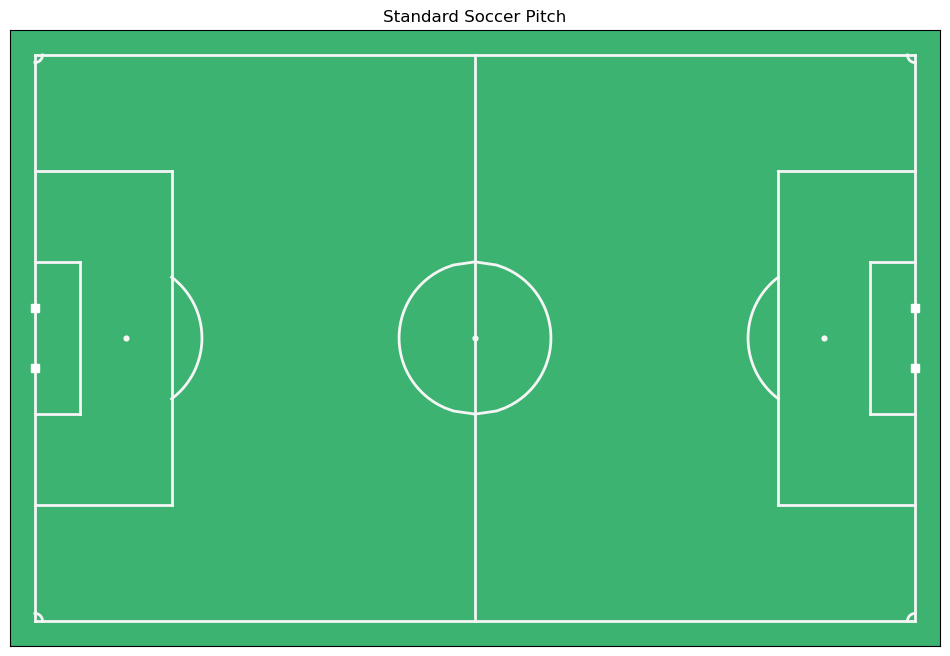

In [653]:
#Visual representation of a standard soccer pitch
ffig, ax = mviz.plot_pitch()
ax.set_title("Standard Soccer Pitch")
plt.show()

Reading team: home
Reading team: away


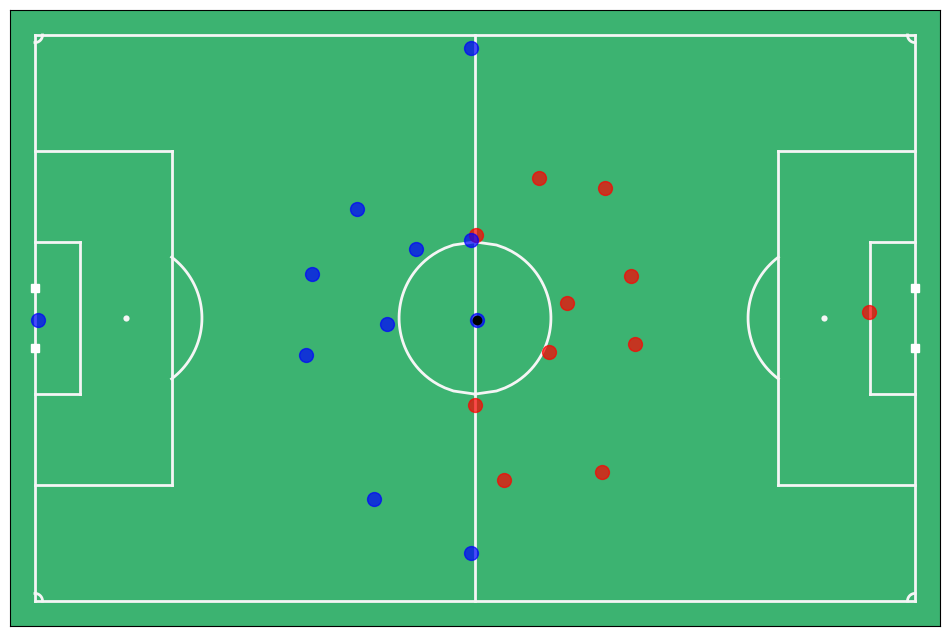

In [654]:
tracking_home = mio.tracking_data(DATADIR,game_id,'Home')
tracking_away = mio.tracking_data(DATADIR,game_id,'Away')

# Convert positions from metrica units to meters 
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)


# Plot player positions at ,atckick-off
KO_Frame = events.loc[0]['Start Frame']
fig,ax = mviz.plot_frame( tracking_home.loc[KO_Frame], tracking_away.loc[KO_Frame] )


In [655]:
#Create a seperate data set for passes only
passes = events.loc[events["Type"]=="PASS"]
passes["Subtype"].unique()

array([nan, 'HEAD', 'CROSS', 'DEEP BALL', 'GOAL KICK',
       'HEAD-INTERCEPTION-CLEARANCE'], dtype=object)

In [656]:
passes

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
1,Away,PASS,NaN,1,51,2.04,87,3.48,Player23,Player20,0.00,-0.00,-10.60,-0.68
2,Away,PASS,NaN,1,146,5.84,186,7.44,Player20,Player18,-7.42,-0.00,-6.36,19.04
3,Away,PASS,NaN,1,248,9.92,283,11.32,Player18,Player17,-3.18,21.08,-20.14,14.96
4,Away,PASS,NaN,1,316,12.64,346,13.84,Player17,Player16,-22.26,12.24,-25.44,-5.44
5,Away,PASS,NaN,1,395,15.80,423,16.92,Player16,Player15,-25.44,-10.88,-24.38,-27.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914,Home,PASS,NaN,2,137209,5488.36,137221,5488.84,Player1,Player6,-9.54,12.24,-4.24,4.76
1915,Home,PASS,NaN,2,137263,5490.52,137303,5492.12,Player6,Player1,-4.24,12.24,-12.72,21.76
1916,Home,PASS,NaN,2,137303,5492.12,137332,5493.28,Player1,Player5,-12.72,21.76,-1.06,26.52
1917,Home,PASS,NaN,2,137334,5493.36,137359,5494.36,Player5,Player1,-1.06,26.52,-15.90,26.52


/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/795351659.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_red = cm.get_cmap('Reds')
/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/795351659.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blue = cm.get_cmap('Blues')


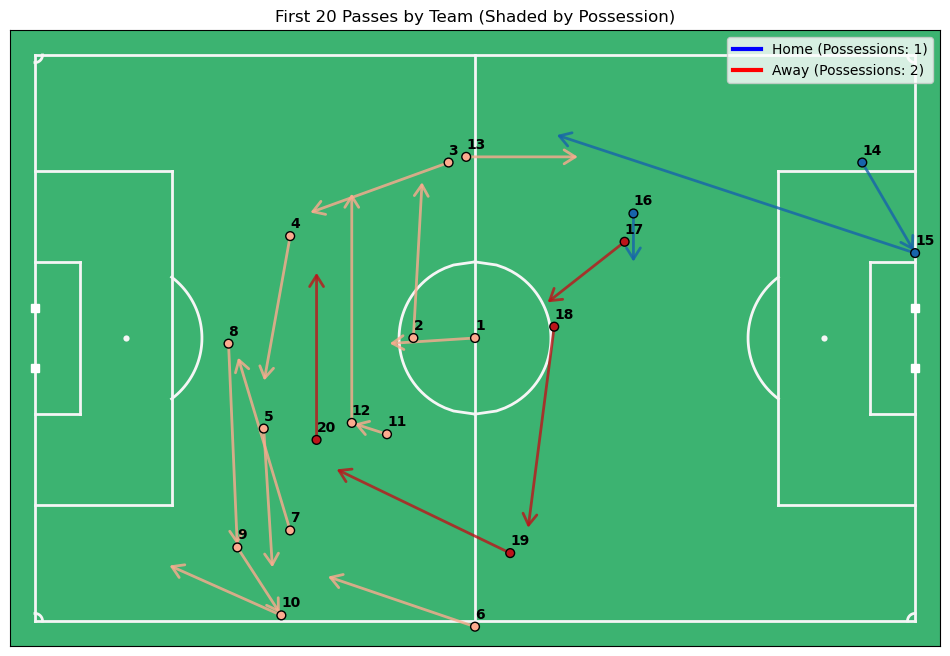

In [657]:
import matplotlib.cm as cm

# STEP 1: Compute "Possession" for each team
#Posession is the grouping of frames that the team has the ball for until oponent steals
passes = passes.copy()
passes['Possession'] = (passes['Team'] != passes['Team'].shift(1)).cumsum()

# STEP 2:Consider first 20 passes
first20_passes = passes.head(20)

# STEP 3: Determine max number of possessions for each team
max_possession_home = first20_passes[first20_passes['Team']=='Home']['Possession'].max()
max_possession_away = first20_passes[first20_passes['Team']=='Away']['Possession'].max()

# STEP 4: Colormaps
cmap_red = cm.get_cmap('Reds')
cmap_blue = cm.get_cmap('Blues')

# STEP 5: Plot the field and label
fig, ax = mviz.plot_pitch()
ax.set_title("First 20 Passes by Team (Shaded by Possession)")

# STEP 6: Plot arrows and label passes
for i, (_, row) in enumerate(first20_passes.iterrows(), start=1):
    team = row['Team']
    
    if team == "Home":
        #make color get darker with increased possession counts(reasoning for color maps)
        possession_scaled = 0.3 + 0.5 * (row['Possession'] - 1) / max(1, max_possession_home-1)
        color = cmap_blue(possession_scaled)
    else: 
        possession_scaled = 0.3 + 0.5 * (row['Possession'] - 1) / max(1, max_possession_away-1)
        color = cmap_red(possession_scaled)

    # plot arrows
    ax.annotate("",
                xy=row[['End X', 'End Y']],
                xytext=row[['Start X', 'Start Y']],
                arrowprops=dict(arrowstyle="->,head_length=0.8,head_width=0.5",
                                color=color, lw=2, alpha=0.8),
                annotation_clip=False)
    
    # Label pass number
    ax.text(row['Start X'], row['Start Y']+1, str(i), color='black', fontsize=10, weight='bold')

# STEP 7: Plot start points 
for team in ["Home", "Away"]:
    team_passes = first20_passes[first20_passes['Team'] == team]
    if team == "Home":
        colors = [cmap_blue(0.3 + 0.5 * (p-1)/max(1,max_possession_home-1)) for p in team_passes['Possession']]
    else:
        colors = [cmap_red(0.3 + 0.5 * (p-1)/max(1,max_possession_away-1)) for p in team_passes['Possession']]
    ax.scatter(team_passes['Start X'], team_passes['Start Y'],
               c=colors, s=40, edgecolors='k', zorder=5)

#STEP 8: Legend for team colors + possession counts
handles, labels = [], []
for team, base_color in {"Home": "blue", "Away": "red"}.items():
    count = first20_passes[first20_passes['Team'] == team]['Possession'].nunique()
    handles.append(plt.Line2D([0],[0], color=base_color, lw=3))
    labels.append(f"{team} (Possessions: {count})")
ax.legend(handles, labels, loc='upper right')

plt.show()



In [847]:
# --- PIF Factor #1: Location of Pass ---
goal_box = 11
pitch_length = 105  # total pitch length

# Filter out passes starting inside goal box (relative to center)
def outside_goal_box(row):
    half_pitch = pitch_length / 2
    if row['Team'] == "Home" and row['Start X'] <= -half_pitch + goal_box:
        return False
    if row['Team'] == "Away" and row['Start X'] >= half_pitch - goal_box:
        return False
    return True

passes = passes[passes.apply(outside_goal_box, axis=1)].copy()

# Adjust sides at half-time so all attacks are left → right
def adjust_x(row):
    if row['Period'] == 2:
        return -row['Start X'], -row['End X']
    else:
        return row['Start X'], row['End X']

passes[['Start_X_adj', 'End_X_adj']] = passes.apply(lambda r: adjust_x(r), axis=1, result_type='expand')

# Assign Third-of-Field based on adjusted coordinates (center = 0)
def field_third_centered(x):
    third_width = pitch_length / 6  # because pitch runs -52.5 → +52.5
    if x < -third_width:
        return "Defensive"
    elif x < third_width:
        return "Middle"
    else:
        return "Attacking"

passes['Third'] = passes['Start_X_adj'].apply(field_third_centered)

# Assign "Bonus" for thirds
third_bonus = {"Defensive": 1.5, "Middle": 1.4, "Attacking": 1.5}
passes['Third_Bonus'] = passes['Third'].map(third_bonus)


In [848]:
# === PIF FACTOR #2: Progressiveness of the ball ===
# How far has the ball travelled forward/backward?

def prog_score_centered(row):
    # Use adjusted coordinates so all attacks are left->right
    dx = row['End_X_adj'] - row['Start_X_adj']

    if dx > 0:
        # Forward pass: full reward
        return dx / 10  
    else:
        # Backward pass: still give some credit
        # Own half = Start_X_adj < 0
        if row['Start_X_adj'] < 0:
            # Defensive half: recycling under pressure
            return abs(dx) / 20
        else:
            # Attacking half: can set up chances
            return abs(dx) / 15

# Apply to all passes
passes['delta_x'] = passes['End_X_adj'] - passes['Start_X_adj']
passes['Prog_Score'] = passes.apply(prog_score_centered, axis=1)



In [849]:
# --- PIF FACTOR #3: Possession of the ball ---
# How long has the team been controlling the play?

events = events.copy()

# Ensure Possession column exists
if 'Possession' not in events.columns:
    events['Possession'] = (events['Team'] != events['Team'].shift(1)).cumsum()

# STEP 1: Compute possession durations
possession_times = (
    events.groupby('Possession')['Start Time [s]']
    .agg(['min', 'max'])
    .reset_index()
)
possession_times['duration'] = possession_times['max'] - possession_times['min']

# STEP 2: Merge duration into passes safely
if 'Possession' not in passes.columns:
    passes['Possession'] = (passes['Team'] != passes['Team'].shift(1)).cumsum()

# Drop any existing 'duration' column in passes to avoid merge conflicts
if 'duration' in passes.columns:
    passes = passes.drop(columns=['duration'])

passes = passes.merge(
    possession_times[['Possession', 'duration']],
    on='Possession',
    how='left'
)

# STEP 3: Time bonus
# Backward-compatible: give bonus only if possession duration > 5s
passes['Time_Bonus'] = passes['duration'].apply(lambda d: d/5 if pd.notna(d) and d > 5 else 0)



In [919]:
# --- Normalize each factor to 0–1 ---
passes_filtered['Prog_Score_N'] = (
    passes_filtered['Prog_Score'] - passes_filtered['Prog_Score'].min()
) / (passes_filtered['Prog_Score'].max() - passes_filtered['Prog_Score'].min())

passes_filtered['Time_Bonus_N'] = (
    passes_filtered['Time_Bonus'] - passes_filtered['Time_Bonus'].min()
) / (passes_filtered['Time_Bonus'].max() - passes_filtered['Time_Bonus'].min())

passes_filtered['Third_Bonus_N'] = (
    passes_filtered['Third_Bonus'] - passes_filtered['Third_Bonus'].min()
) / (passes_filtered['Third_Bonus'].max() - passes_filtered['Third_Bonus'].min())

# --- Weighted sum ---
weight_prog = 0.4
weight_time = 0.3
weight_third = 0.3

# --- Linear combination of normalized factors ---
passes_filtered['PIF_Raw'] = (
    weight_prog * passes_filtered['Prog_Score_N'] +
    weight_time * passes_filtered['Time_Bonus_N'] +
    weight_third * passes_filtered['Third_Bonus_N']
)

# --- Rescale to 1–5 ---
pif_min, pif_max = passes_filtered['PIF_Raw'].min(), passes_filtered['PIF_Raw'].max()
passes_filtered['PIF_Scaled'] = ((passes_filtered['PIF_Raw'] - pif_min) / (pif_max - pif_min)) * 4 + 1

# --- Check ---
passes_filtered['PIF_Scaled'].describe()


count    884.000000
mean       2.252097
std        0.934775
min        1.000000
25%        1.384562
50%        1.960827
75%        3.038180
max        5.000000
Name: PIF_Scaled, dtype: float64

In [920]:
##Top passes based on PIF in Game 2 

# Sort passes by PIF_Scaled descending
top_passes = passes_filtered.sort_values('PIF_Scaled', ascending=False)

# Keep top 10 passes
top_passes = top_passes.head(10)

#Display Top Passes 
top_passes = top_passes[['Team', 'From', 'To', 'Start X', 'Start Y', 'End X', 'End Y', 'PIF_Raw', 'PIF_Scaled']]
top_passes


,Team,From,To,Start X,Start Y,End X,End Y,PIF_Raw,PIF_Scaled
118,Home,Player3,Player11,36.04,-21.08,48.76,0.68,0.693429,5.000000
115,Home,Player7,Player4,29.68,-24.48,40.28,-27.88,0.673429,4.884631
119,Home,Player5,Player2,19.08,25.16,26.50,26.52,0.643429,4.711578
113,Home,Player6,Player4,31.80,-29.92,37.10,-27.20,0.623429,4.596210
114,Home,Player4,Player7,37.10,-27.20,29.68,-24.48,0.620096,4.576982
120,Home,Player2,Player1,26.50,27.20,20.14,32.64,0.613429,4.538525
449,Home,Player11,Player7,48.76,-6.12,-1.06,-25.84,0.613333,4.537972
116,Home,Player4,Player6,34.98,-26.52,30.74,-31.96,0.600096,4.461613
193,Home,Player2,Player11,26.50,-22.44,48.76,-10.20,0.583126,4.363726
70,Away,Player16,Player23,-38.16,2.04,-8.48,14.96,0.580000,4.345691


/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/1238626356.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_home = cm.get_cmap('Blues')
/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/1238626356.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_away = cm.get_cmap('Reds')


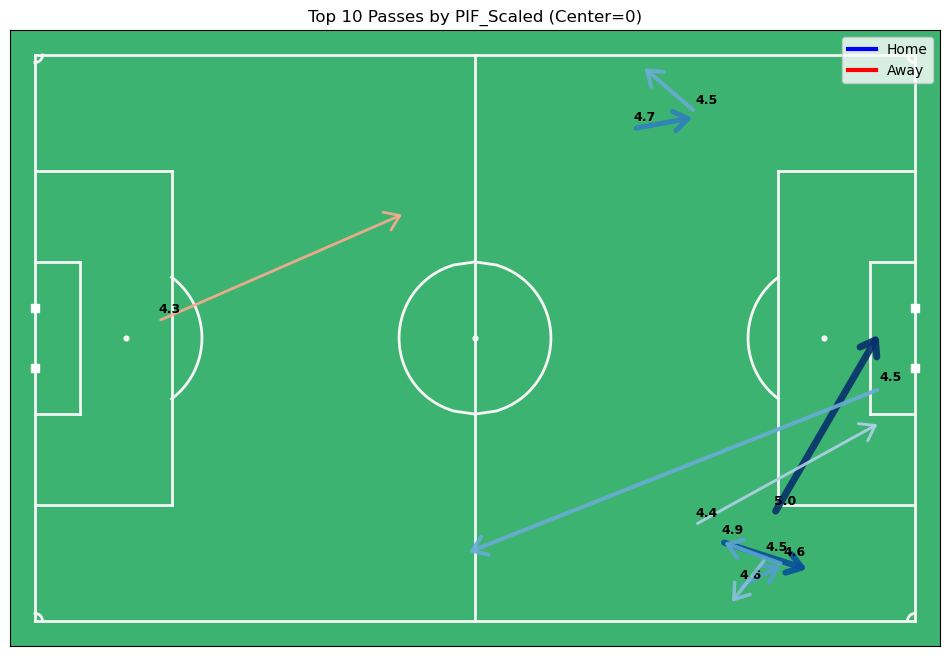

In [921]:
#import matplotlib.pyplot as plt
from matplotlib import cm

# Plot pitch (centered at 0)
fig, ax = mviz.plot_pitch()
ax.set_title("Top 10 Passes by PIF_Scaled (Center=0)")

# Colormaps
cmap_home = cm.get_cmap('Blues')
cmap_away = cm.get_cmap('Reds')

min_pif, max_pif = top_passes['PIF_Scaled'].min(), top_passes['PIF_Scaled'].max()

# Plot arrows
for _, row in top_passes.iterrows():
    norm_pif = 0.3 + 0.7 * (row['PIF_Scaled'] - min_pif) / (max_pif - min_pif)
    lw = 2 + 3 * ((row['PIF_Scaled'] - min_pif) / (max_pif - min_pif))
    color = cmap_home(norm_pif) if row['Team']=='Home' else cmap_away(norm_pif)

    ax.annotate("",
                xy=(row['End X'], row['End Y']),
                xytext=(row['Start X'], row['Start Y']),
                arrowprops=dict(arrowstyle="->,head_length=1,head_width=0.7",
                                color=color, lw=lw, alpha=0.9),
                annotation_clip=False)

    ax.text(row['Start X'], row['Start Y']+1, f"{row['PIF_Scaled']:.1f}", 
            color='black', fontsize=9, weight='bold')

# Legend
handles = [plt.Line2D([0],[0], color='blue', lw=3),
           plt.Line2D([0],[0], color='red', lw=3)]
ax.legend(handles, ['Home', 'Away'], loc='upper right')

plt.show()



In [922]:
# Sort passes by PIF_Scaled ascending (lowest first)
worst = passes_filtered.sort_values('PIF_Scaled', ascending=True)
# Keep worst 10 passes
worst_passes = worst.head(10)

# Display columns
worst_passes = worst_passes[['Team', 'From', 'To', 'Start X', 'Start Y', 'End X', 'End Y', 'PIF_Raw', 'PIF_Scaled']]
worst_passes




,Team,From,To,Start X,Start Y,End X,End Y,PIF_Raw,PIF_Scaled
512,Home,Player8,Player5,-14.84,18.36,-14.84,2.72,0.0,1.0
201,Away,Player16,Player15,-8.48,-10.20,-8.48,-29.24,0.0,1.0
276,Away,Player21,Player20,-15.90,-19.04,-15.90,-9.52,0.0,1.0
546,Away,Player17,Player16,11.66,2.04,11.66,17.68,0.0,1.0
453,Home,Player10,Player8,-2.12,-21.08,-2.12,-0.68,0.0,1.0
37,Home,Player6,Player9,-10.60,15.64,-10.60,21.08,0.0,1.0
333,Away,Player21,Player17,-5.30,-10.20,-5.30,11.56,0.0,1.0
434,Home,Player5,Player4,3.18,-1.36,3.18,-16.32,0.0,1.0
903,Home,Player14,Player13,-1.06,-29.92,-1.06,-22.44,0.0,1.0
613,Home,Player4,Player6,13.78,29.24,13.78,14.96,0.0,1.0


/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/2104010038.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_home = cm.get_cmap('Blues')
/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/2104010038.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_away = cm.get_cmap('Reds')


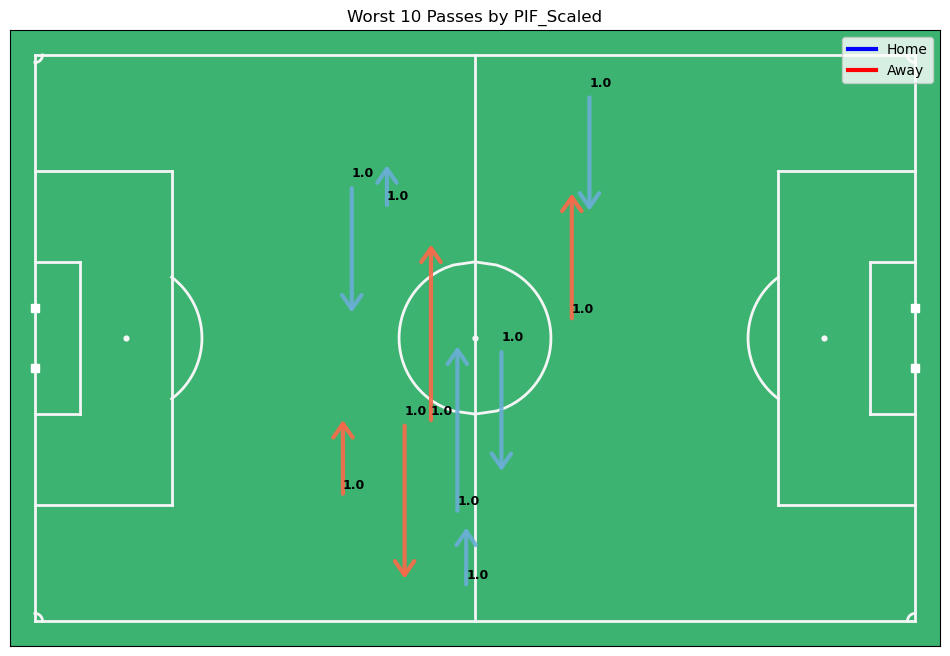

In [923]:
# --- Step 1: Plot pitch ---
fig, ax = mviz.plot_pitch()
ax.set_title("Worst 10 Passes by PIF_Scaled")

# Colormaps
cmap_home = cm.get_cmap('Blues')
cmap_away = cm.get_cmap('Reds')

# Get min/max for normalization
min_pif, max_pif = worst_passes['PIF_Scaled'].min(), worst_passes['PIF_Scaled'].max()

# --- Step 2: Plot arrows for each pass ---
for _, row in worst_passes.iterrows():
    # Normalize for color and line width
    if max_pif != min_pif:
        norm_pif = 0.3 + 0.7 * (row['PIF_Scaled'] - min_pif) / (max_pif - min_pif)
        lw = 2 + 3 * ((row['PIF_Scaled'] - min_pif) / (max_pif - min_pif))
    else:
        norm_pif = 0.5  # middle value if all equal
        lw = 3          # default line width

    color = cmap_home(norm_pif) if row['Team'] == 'Home' else cmap_away(norm_pif)

    ax.annotate("",
                xy=(row['End X'], row['End Y']),
                xytext=(row['Start X'], row['Start Y']),
                arrowprops=dict(arrowstyle="->,head_length=1,head_width=0.7",
                                color=color, lw=lw, alpha=0.9),
                annotation_clip=False)

    ax.text(row['Start X'], row['Start Y']+1,
            f"{row['PIF_Scaled']:.1f}",
            color='black', fontsize=9, weight='bold')

# --- Step 3: Add legend ---
handles = [plt.Line2D([0],[0], color='blue', lw=3),
           plt.Line2D([0],[0], color='red', lw=3)]
ax.legend(handles, ['Home', 'Away'], loc='upper right')

plt.show()



In [924]:
 # --- Step 0: Exclude goalkeeper passes (already done in passes_filtered) ---
# passes_filtered already excludes Player1 and Player25

# --- Step 1: Identify all goals ---
goals = events[(events["Type"] == "SHOT") & 
               (events["Subtype"].str.contains("GOAL", na=False))].copy()

goals = goals.sort_values(["Period", "Start Frame"]).reset_index(drop=True)
goals["Goal#"] = goals.index + 1  # numbering goals

# --- Step 2: Get last 3 passes before each goal ---
goal_passes = []

for _, goal in goals.iterrows():
    g_period = goal["Period"]
    g_frame = goal["Start Frame"]

    # Get passes from filtered passes (excludes goalkeepers) in the same period
    passes_before = passes_filtered[
    (passes_filtered["Period"] == g_period) &
    (passes_filtered["Start Frame"] < g_frame)
    ].copy()

    # Take the last 3 passes
    last3 = passes_before.tail(3).copy()
    last3["Goal#"] = goal["Goal#"]

    # Number passes relative to goal (3 = farthest, 1 = closest)
    last3["Pass_Number_To_Goal"] = range(len(last3), 0, -1)

    goal_passes.append(last3)

# --- Step 3: Concatenate all goal passes ---
goal_passes_table = pd.concat(goal_passes, ignore_index=True)


# --- Step 5: Keep relevant columns ---
goal_passes_table = goal_passes_table[[
    "Goal#", "Pass_Number_To_Goal", "Team", "From", "To",
    "Start X", "Start Y", "End X", "End Y",
    "PIF_Raw", "PIF_Scaled"
]].reset_index(drop=True)

goal_passes_table




,Goal#,Pass_Number_To_Goal,Team,From,To,Start X,Start Y,End X,End Y,PIF_Raw,PIF_Scaled
0,1,3,Home,Player9,Player8,-32.86,0.68,-39.22,-25.16,0.4624,3.667322
1,1,2,Home,Player8,Player9,-41.34,-24.48,-42.40,-14.96,0.4374,3.523111
2,1,1,Home,Player8,Player1,-28.62,-7.48,-37.10,23.80,0.4724,3.725006
3,2,3,Away,Player21,Player19,2.12,12.92,30.74,-26.52,0.2700,2.557477
4,2,2,Away,Player19,Player23,30.74,-27.20,37.10,-15.64,0.3600,3.076636
5,2,1,Away,Player23,Player24,41.34,-9.52,44.52,2.72,0.3300,2.903583
6,3,3,Home,Player8,Player9,27.56,21.08,36.04,4.08,0.3400,2.961267
7,3,2,Home,Player10,Player8,39.22,8.16,43.46,19.04,0.3200,2.845899
8,3,1,Home,Player8,Player9,46.64,19.72,47.70,-1.36,0.3050,2.759372
9,4,3,Away,Player18,Player19,-24.38,-15.64,-33.92,-26.52,0.3900,3.249689


/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/3190702694.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_home = cm.get_cmap("Blues")
/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/3190702694.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_away = cm.get_cmap("Reds")


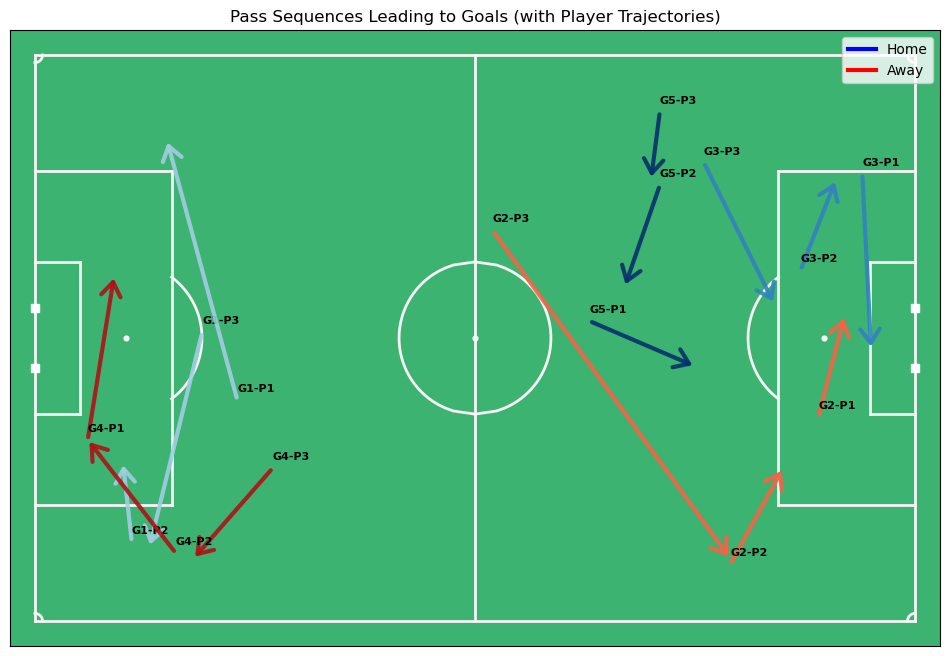

In [925]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Plot pitch
fig, ax = mviz.plot_pitch()
ax.set_title("Pass Sequences Leading to Goals (with Player Trajectories)")

cmap_home = cm.get_cmap("Blues")
cmap_away = cm.get_cmap("Reds")

# loop over goals
for goal_num, group in goal_passes_table.groupby("Goal#"):
    # shading intensity: earlier goals darker, later goals lighter
    norm_shade = 0.2 + 0.8 * (goal_num / goal_passes_table["Goal#"].max())

    for _, row in group.iterrows():
        color = cmap_home(norm_shade) if row["Team"] == "Home" else cmap_away(norm_shade)

        # --- PASS ARROWS ---
        ax.annotate(
            "",
            xy=(row["End X"], row["End Y"]),
            xytext=(row["Start X"], row["Start Y"]),
            arrowprops=dict(
                arrowstyle="->,head_length=1,head_width=0.7",
                color=color, lw=3, alpha=0.9,
            ),
            annotation_clip=False,
        )

        # Label pass
        ax.text(
            row["Start X"],
            row["Start Y"] + 1,
            f"G{goal_num}-P{row['Pass_Number_To_Goal']}",
            color="black",
            fontsize=8,
            weight="bold",
        )

        # --- PLAYER TRAJECTORY ---
        tracking = tracking_home if row["Team"] == "Home" else tracking_away

        # get player column name
        player_id = row["From"]
        if player_id in tracking.columns:
            traj = tracking.loc[
                (tracking["Period"] == goals.loc[goal_num-1, "Period"]) &
                (tracking["Time [s]"] >= row["Start Time [s]"]) &
                (tracking["Time [s]"] <= row["End Time [s]"])
            , [f"{player_id}_x", f"{player_id}_y"]]

            ax.plot(traj[f"{player_id}_x"], traj[f"{player_id}_y"],
                    color=color, lw=1.5, alpha=0.6, linestyle="--")

# Legend
handles = [plt.Line2D([0],[0], color='blue', lw=3),
           plt.Line2D([0],[0], color='red', lw=3)]
ax.legend(handles, ['Home', 'Away'], loc='upper right')

plt.show()


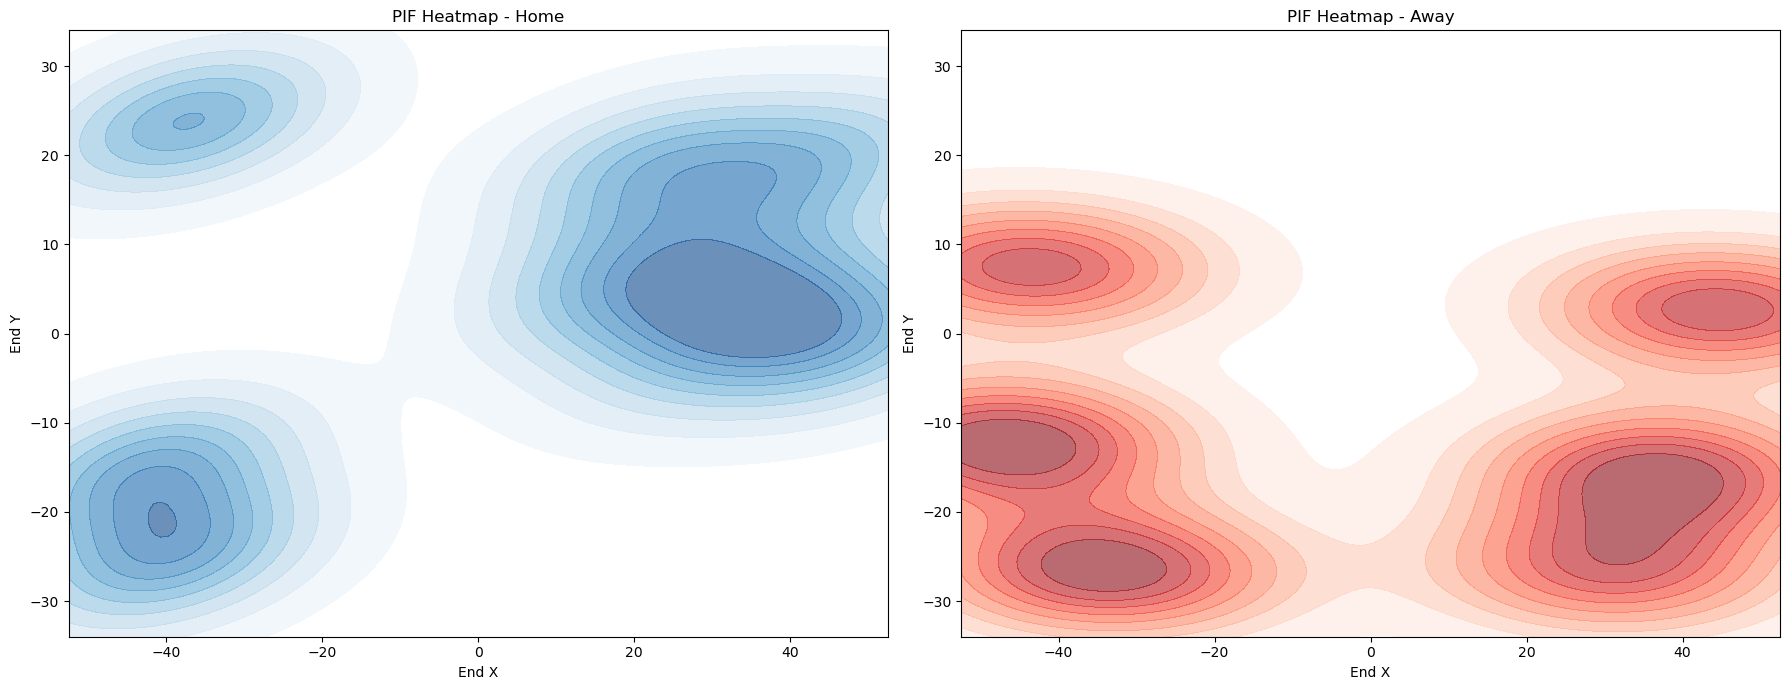

In [926]:
#Heat map of passes PIF_Scaled values that lead to Goals
import seaborn as sns

# --- Setup figure with 2 subplots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

teams = ["Home", "Away"]

colors = ["Blues", "Reds"]

for ax, team, cmap in zip(axes, teams, colors):
    

    team_data = goal_passes_table[goal_passes_table["Team"] == team]

    if not team_data.empty:
        sns.kdeplot(
            x=team_data["End X"],
            y=team_data["End Y"],
            weights=team_data["PIF_Scaled"],
            cmap=cmap,
            fill=True,
            alpha=0.6,
            bw_adjust=0.5,  # smoothing
            ax=ax,
            thresh=0.05
        )

    ax.set_xlim(-105/2, 105/2)
    ax.set_ylim(-68/2, 68/2)
    ax.set_title(f"PIF Heatmap - {team}")

plt.tight_layout()
plt.show()



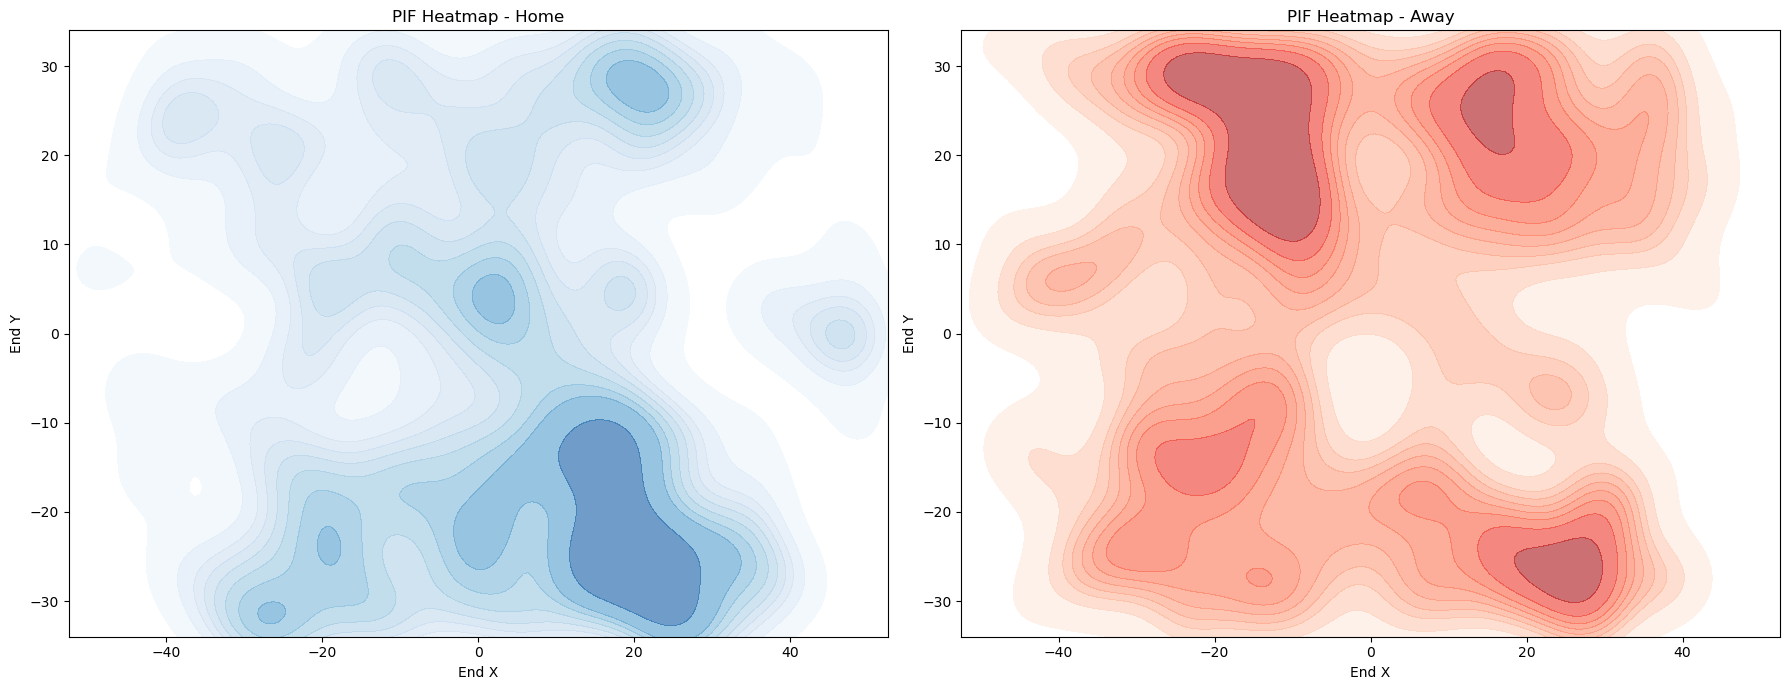

In [927]:
#Heat map of all passes PIF_Scaled values in Game
import seaborn as sns

# --- Setup figure with 2 subplots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

teams = ["Home", "Away"]

colors = ["Blues", "Reds"]

for ax, team, cmap in zip(axes, teams, colors):
    team_data = passes_filtered[passes_filtered['Team'] == team]

    if not team_data.empty:
        sns.kdeplot(
            x=team_data["End X"],
            y=team_data["End Y"],
            weights=team_data["PIF_Scaled"],
            cmap=cmap,
            fill=True,
            alpha=0.6,
            bw_adjust=0.5,  # smoothing
            ax=ax,
            thresh=0.05
        )

    ax.set_xlim(-105/2, 105/2)
    ax.set_ylim(-68/2, 68/2)
    ax.set_title(f"PIF Heatmap - {team}")

plt.tight_layout()
plt.show()



/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_42557/520439584.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


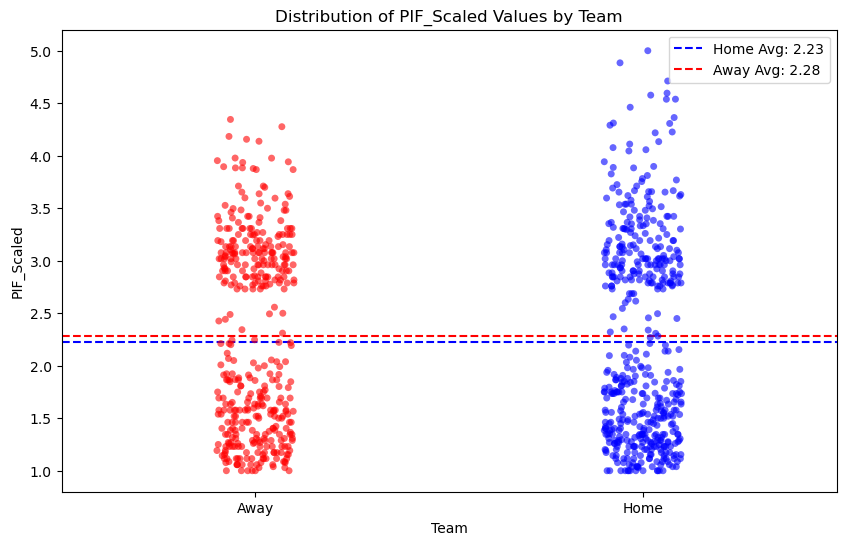

In [928]:
#Distribution of all PIF_Scaled values by Team.

import seaborn as sns


# Compute averages
avg_home = passes_filtered[passes_filtered['Team'] == 'Home']['PIF_Scaled'].mean()
avg_away = passes_filtered[passes_filtered['Team'] == 'Away']['PIF_Scaled'].mean()

plt.figure(figsize=(10, 6))

# Strip plot for all PIF_Scaled values
sns.stripplot(
    x='Team',
    y='PIF_Scaled',
    data=passes_filtered,
    jitter=True,
    palette={'Home': 'blue', 'Away': 'red'},
    alpha=0.6
)

# Overlay averages as horizontal lines
plt.axhline(avg_home, color='blue', linestyle='--', label=f'Home Avg: {avg_home:.2f}')
plt.axhline(avg_away, color='red', linestyle='--', label=f'Away Avg: {avg_away:.2f}')

plt.title('Distribution of PIF_Scaled Values by Team')
plt.ylabel('PIF_Scaled')
plt.xlabel('Team')
plt.legend()
plt.show()


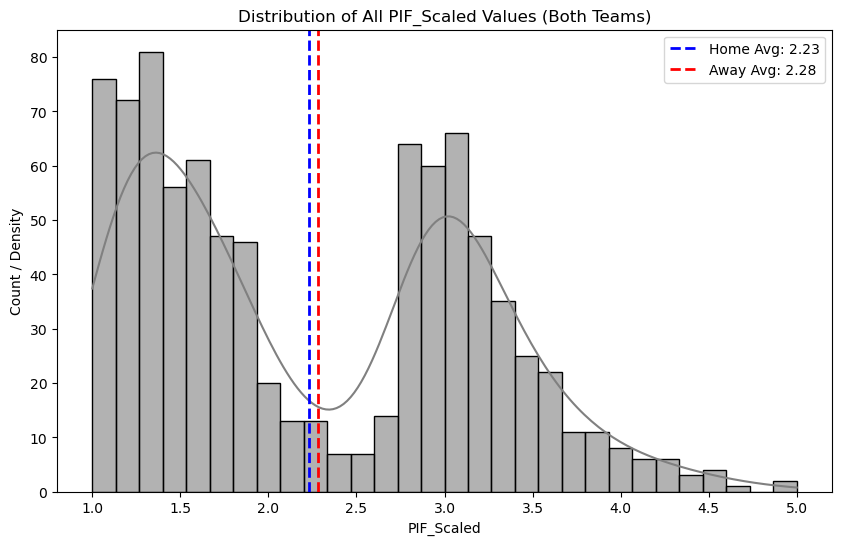

In [929]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute averages per team
avg_home = passes_filtered[passes_filtered['Team'] == 'Home']['PIF_Scaled'].mean()
avg_away = passes_filtered[passes_filtered['Team'] == 'Away']['PIF_Scaled'].mean()

plt.figure(figsize=(10, 6))

# Single distribution for all passes
sns.histplot(passes_filtered['PIF_Scaled'], bins=30, kde=True, color='grey', alpha=0.6)

# Overlay team averages
plt.axvline(avg_home, color='blue', linestyle='--', linewidth=2, label=f'Home Avg: {avg_home:.2f}')
plt.axvline(avg_away, color='red', linestyle='--', linewidth=2, label=f'Away Avg: {avg_away:.2f}')

plt.title('Distribution of All PIF_Scaled Values (Both Teams)')
plt.xlabel('PIF_Scaled')
plt.ylabel('Count / Density')
plt.legend()
plt.show()
